In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
from grid.src.functions import *

In [2]:
with open('../SingleBlade/Output/SRV2.pik', 'rb') as f:
    data = pickle.load(f)

In [3]:
blade = data.blades[0]
kappa = blade.blade_metal_angle

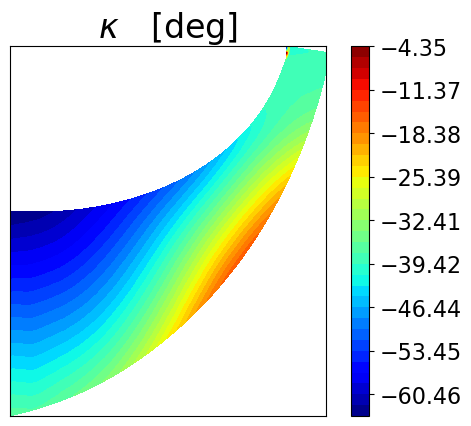

In [4]:
contour_template(blade.z_grid, blade.r_grid, 180/np.pi*kappa, r'$\kappa \quad \mathrm{[deg]}$')

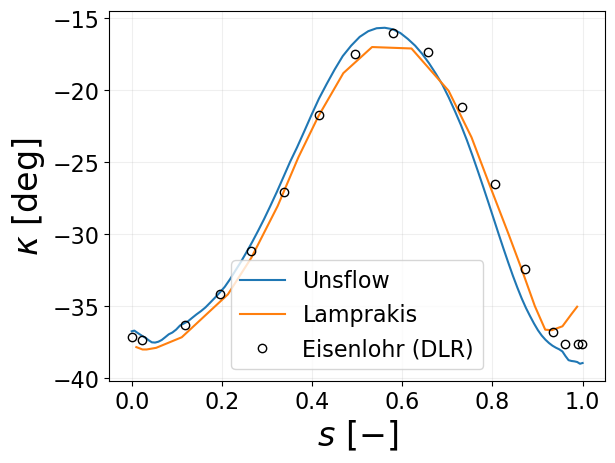

In [15]:
lamprakis_hub = np.loadtxt('lamprakis_hub.csv', delimiter=',', skiprows=1)
dlr_hub = np.loadtxt('dlr_hub.csv', delimiter=',', skiprows=1)

lamprakis_shroud = np.loadtxt('lamprakis_shroud.csv', delimiter=',', skiprows=1)

plt.figure()
plt.plot(blade.streamwise_normalized_coord[:,0], 180/np.pi*blade.blade_metal_angle[:,0], label='Unsflow')
plt.plot(lamprakis_hub[:,0], lamprakis_hub[:,1], 'C1', mfc='none', label='Lamprakis')
plt.plot(dlr_hub[:,0], dlr_hub[:,1]-90, 'ko', mfc='none', label='Eisenlohr (DLR)')

plt.xlabel(r'$s \ \mathrm{[-]}$')
plt.ylabel(r'$\kappa \ \mathrm{[deg]}$')
plt.legend()
plt.grid(alpha=grid_opacity)

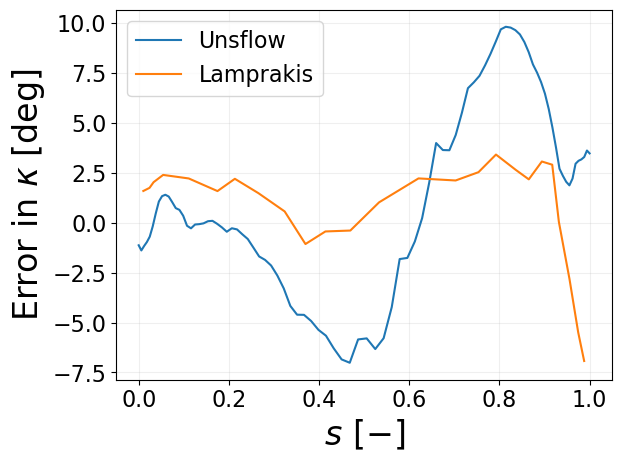

In [20]:
# plot the errors
xunsflow = blade.streamwise_normalized_coord[:,0]
ytrue = np.interp(xunsflow, dlr_hub[:,0], dlr_hub[:,1]-90)
err_unsflow = (180/np.pi*blade.blade_metal_angle[:,0] - ytrue)/ytrue*100

xlamprakis = lamprakis_hub[:,0]
ytrue = np.interp(xlamprakis, dlr_hub[:,0], dlr_hub[:,1]-90)
err_lamprakis = (lamprakis_hub[:,1] - ytrue)/ytrue*100

plt.figure()
plt.plot(xunsflow, err_unsflow, label='Unsflow')
plt.plot(xlamprakis, err_lamprakis, 'C1', mfc='none', label='Lamprakis')
plt.xlabel(r'$s \ \mathrm{[-]}$')
plt.ylabel(r'Error in $\kappa \ \mathrm{[deg]}$')
plt.legend()
plt.grid(alpha=grid_opacity)

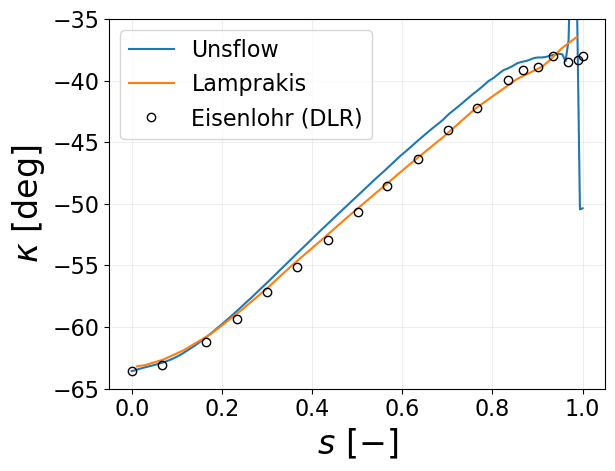

In [13]:
lamprakis_shroud = np.loadtxt('lamprakis_shroud.csv', delimiter=',', skiprows=1)
dlr_shroud = np.loadtxt('dlr_shroud.csv', delimiter=',', skiprows=1)

plt.figure()
plt.plot(blade.streamwise_normalized_coord[:,-2], 180/np.pi*blade.blade_metal_angle[:,-3], label='Unsflow')
plt.plot(lamprakis_shroud[:,0], lamprakis_shroud[:,1], 'C1', mfc='none', label='Lamprakis')
plt.plot(dlr_shroud[:,0], dlr_shroud[:,1]-90, 'ko', mfc='none', label='Eisenlohr (DLR)')
plt.ylim([-65, -35])
plt.xlabel(r'$s \ \mathrm{[-]}$')
plt.ylabel(r'$\kappa \ \mathrm{[deg]}$')
plt.legend()
plt.grid(alpha=grid_opacity)